In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import optax
from flax import nnx
import orbax.checkpoint as ocp

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.utils import power_spectrum
from jaxpm.utils import _initialize_pk
from jaxpm.pm import linear_field, lpt, make_ode_fn, pm_forces
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm.nn import MLP, CNN, HybridNet, ResNet3D, ResNetBlock3D
from jaxpm import camels

jax.devices("gpu")

[cuda(id=0)]

In [3]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3

## Loading the snapshots

In [4]:
i_snapshots=[-1]

In [5]:
SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0"

train_dict = camels.load_CV_snapshots(
    SIM,
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
)

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


loading snapshots: 100%|██████████| 1/1 [00:09<00:00,  9.59s/it]


In [6]:
SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1"

test_dict = camels.load_CV_snapshots(
    SIM,
    mesh_per_dim,
    parts_per_dim,
    # i_snapshots=range(1, 33+4, 4),
    i_snapshots=i_snapshots,
)

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


loading snapshots: 100%|██████████| 1/1 [00:09<00:00,  9.19s/it]


# functions

In [7]:
# # vmap over the snapshots
# vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,None))
# vcic_read = jax.vmap(cic_read, in_axes=(0,0))

# vmap over features (like velocity components)
vcic_paint = jax.vmap(cic_paint, in_axes=(None, None, -1), out_axes=-1)
vcic_read = jax.vmap(cic_read, in_axes=(-1, None), out_axes=-1)

def preprocess(snapshot_dict):
    cosmo = snapshot_dict["cosmo"]
    scales = snapshot_dict["scales"]

    gas_pos = snapshot_dict["gas_poss"]
    gas_vel = snapshot_dict["gas_vels"]

    dm_pos = snapshot_dict["dm_poss"]
    dm_vel = snapshot_dict["dm_vels"]
    
    # rho (exactly like in PM)
    rho_dm = cic_paint(jnp.zeros(mesh_shape), dm_pos, None)
    rho_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos, cosmo.Omega_b / cosmo.Omega_c)
    rho = rho_dm + rho_gas
    gas_rho = cic_read(rho, gas_pos)
    
    # fscalar
    kvec = fftk(mesh_shape)
    delta_k = jnp.fft.rfftn(rho)
    fscalar = jnp.fft.irfftn(delta_k * invnabla_kernel(kvec))
    gas_fscalar = cic_read(fscalar, gas_pos)

    # velocity dispersion
    N_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos, 1)
    gas_N = cic_read(N_gas, gas_pos)

    vel_mean_gas = vcic_paint(jnp.zeros(mesh_shape), gas_pos, gas_vel/gas_N[:,jnp.newaxis])
    gas_vel_mean = vcic_read(vel_mean_gas, gas_pos)
    gas_vel_disp = jnp.sum((gas_vel_mean - gas_vel)**2, axis=-1)

    # velocity divergence
    vel_gas_k = jnp.fft.rfftn(vel_mean_gas, axes=(0,1,2))
    gas_vel_div = [cic_read(jnp.fft.irfftn(gradient_kernel(kvec, i) * vel_gas_k[...,i]), gas_pos) for i in range(len(kvec))]
    gas_vel_div = jnp.stack(gas_vel_div, axis=-1)
    gas_vel_div = jnp.sum(gas_vel_div, axis=-1)

    particle_features = {}
    particle_features["gas_pos"] = gas_pos
    particle_features["gas_rho"] = gas_rho
    particle_features["gas_fscalar"] = gas_fscalar
    particle_features["gas_disp"] = gas_vel_disp
    particle_features["gas_div"] = gas_vel_div
    particle_features["gas_P"] = snapshot_dict["gas_Ps"]

    # TODO
    field_features = {}
    
    return scales, particle_features, field_features
    

In [17]:
def normalized_paint(positions, weights):
    rho_pos = cic_paint(jnp.zeros([mesh_per_dim] * 3), positions)
    pos_rho = cic_read(rho_pos, positions)

    return cic_paint(jnp.zeros(mesh_shape), positions, weights/pos_rho)

def plot_field(field, ax, vlims=None):
    log_sum = jnp.log10(field.sum(axis=0))

    if vlims is None:
        vmin, vmax = log_sum.min(), log_sum.max()
        vlims = (vmin, vmax)
    else:
        vmin, vmax = vlims
    
    return ax.imshow(log_sum, cmap="magma", vmin=vmin, vmax=vmax), vlims, log_sum

def plot_comparison(true_field, pred_field, true_label="CAMELS", pred_label="", quantity_label="P", suptitle=""):
    fig, ax = plt.subplots(figsize=(3*6, 6+1), ncols=3)
    
    im, vlims, true_field_log_sum = plot_field(true_field, ax[0])
    ax[0].set(title=true_label)
    
    im, _, pred_field_log_sum = plot_field(pred_field, ax[1], vlims=vlims)
    ax[1].set(title=pred_label)
    
    fig.colorbar(im, ax=ax[:2], label=f"log(sum({quantity_label}))", orientation="horizontal", shrink=0.6, aspect=20)
        
    residual = true_field_log_sum - pred_field_log_sum
    # lim = np.max(np.abs(residual[np.isfinite(residual)]))
    lim = 1.5

    im = ax[2].imshow(residual, cmap="seismic", vmin=-lim, vmax=lim)
    ax[2].set(title="residual (true - pred)")
    fig.colorbar(im, ax=ax[2], label=f"log(sum({quantity_label}_1)) - log(sum({quantity_label}_2))", orientation="horizontal", shrink=0.6, aspect=10)
    
    for i in range(len(ax)):
        ax[i].set_yticks([])
        ax[i].set_xticks([])
    
    fig.suptitle(suptitle, fontsize=16)

i_scale = 1

In [9]:
def get_train_step(model, optimizer):

    @jax.jit
    def train_step(params, opt_state, x, y):
    
        def loss_fn(params):
            model = nnx.merge(graphdef, params)
            y_pred = model(x)
            loss = jnp.nanmean((y - y_pred) ** 2)
            return loss
        
        loss, grads = jax.value_and_grad(loss_fn)(params)

    
        updates, opt_state = optimizer.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
    
        return params, opt_state, loss

    return train_step


In [10]:
def get_data(snapshot_dict, velocity_features=False):
    scales, particle_features, field_features = preprocess(snapshot_dict)
    
    X_particle = jnp.stack(
        [
            np.log10(particle_features["gas_rho"] + 1),
            np.arcsinh(particle_features["gas_fscalar"]/100)
        ], 
        axis=-1
    )
    if velocity_features:
        x = jnp.stack(
            [
                np.log10(particle_features["gas_disp"] + 1),
                np.arcsinh(particle_features["gas_div"]/100)
            ], 
            axis=-1
        )
        X_particle = jnp.concatenate([X_particle, x], axis=-1)
    
    
    # X_field = jnp.stack([jnp.log10(rho + 1), jnp.arcsinh(fscalar/100)], axis=-1)
    
    Y = jnp.stack([jnp.log10(particle_features["gas_P"] + 1)], axis=-1)

    return X_particle, Y


In [11]:
total_steps = 1_000
batch_size = 1_024
# learning_rate = 1e-3
learning_rate = optax.cosine_decay_schedule(
    init_value=1e-3, 
    decay_steps=total_steps, 
    alpha=0.1
)
clip_norm = 1

optimizer = optax.chain(
    optax.clip_by_global_norm(clip_norm),
    optax.adam(learning_rate)
)
losses = []

# rho, fscalar

In [18]:
X_particle, Y = get_data(train_dict, velocity_features=False)

model = MLP(
    d_in=X_particle.shape[-1], 
    d_out=1, 
    d_hidden=64, 
    n_hidden=4, 
    rngs=nnx.Rngs(0)
)

graphdef, params = nnx.split(model)
opt_state = optimizer.init(params)

train_step = get_train_step(model, optimizer)

100%|██████████| 1000/1000 [00:04<00:00, 237.87it/s]


train
test


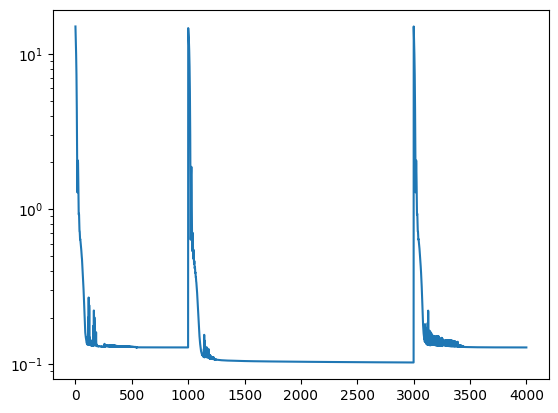

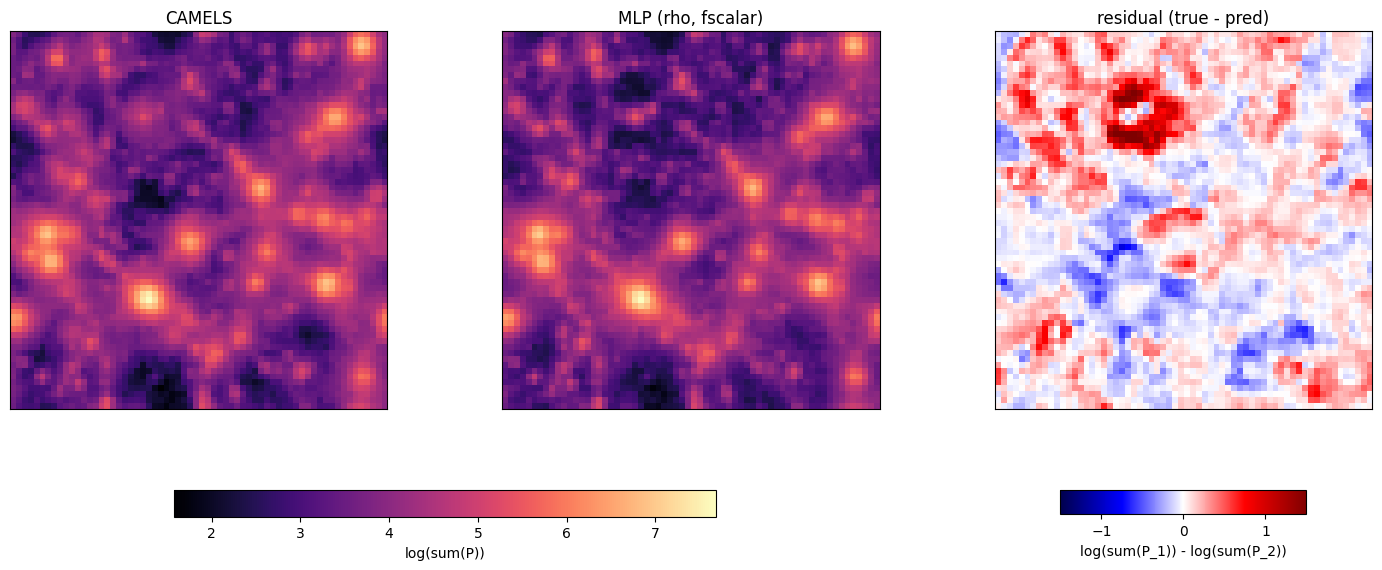

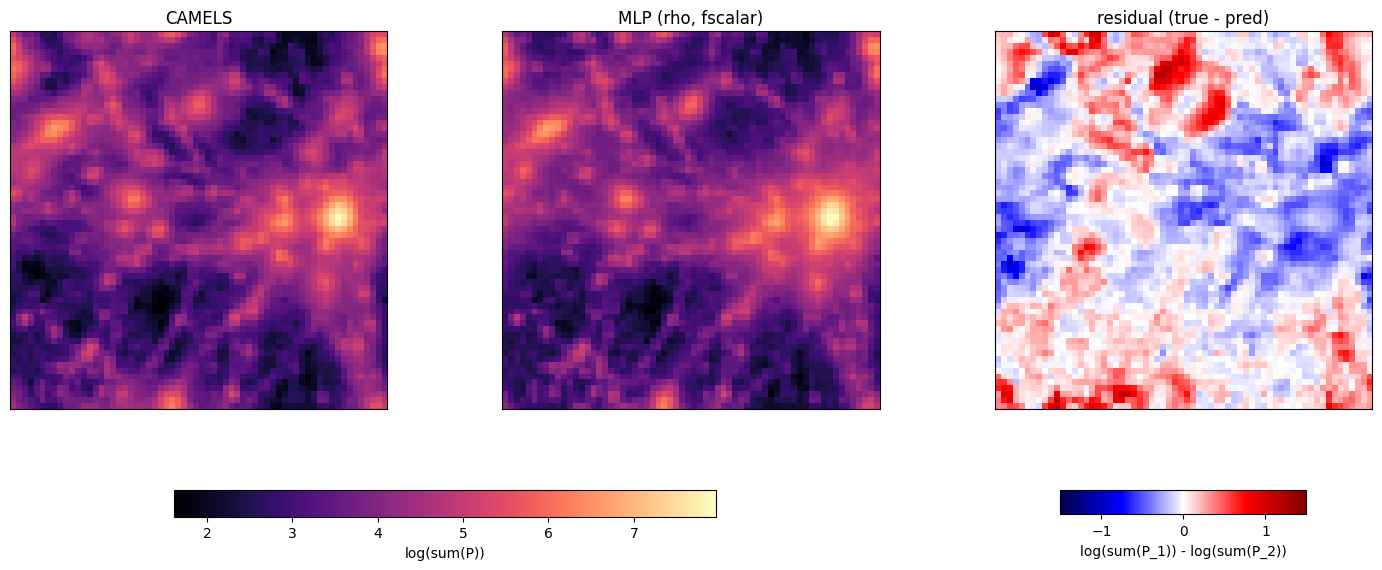

In [19]:
for i in tqdm.tqdm(range(total_steps)):
    x = X_particle
    y = Y
    
    params, opt_state, loss = train_step(params, opt_state, x, y)
    losses.append(loss)

model = nnx.merge(graphdef, params)

fig, ax = plt.subplots()
ax.plot(losses)
ax.set(yscale="log")

for snapshot_dict, label in zip([train_dict, test_dict], ["train", "test"]):
    X_particle_test, Y_test = get_data(snapshot_dict)
    
    gas_P_test = jnp.squeeze(10**model(X_particle_test) - 1)
    P_test = normalized_paint(snapshot_dict["gas_poss"], gas_P_test)
    
    P_camels = normalized_paint(snapshot_dict["gas_poss"], snapshot_dict["gas_Ps"])
    
    plot_comparison(P_camels, P_test, pred_label="MLP (rho, fscalar)")
    print(label)

# rho, fscalar, velocity dispersion, velocity divergence

In [20]:
X_particle, Y = get_data(train_dict, velocity_features=True)

model = MLP(
    d_in=X_particle.shape[-1], 
    d_out=1, 
    d_hidden=64, 
    n_hidden=4, 
    rngs=nnx.Rngs(0)
)

graphdef, params = nnx.split(model)
opt_state = optimizer.init(params)

train_step = get_train_step(model, optimizer)

100%|██████████| 1000/1000 [00:03<00:00, 275.80it/s]


train
test


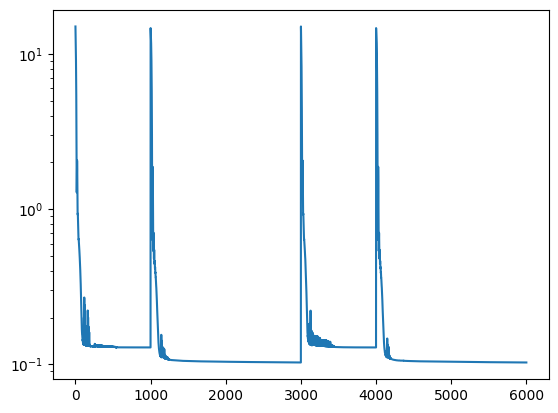

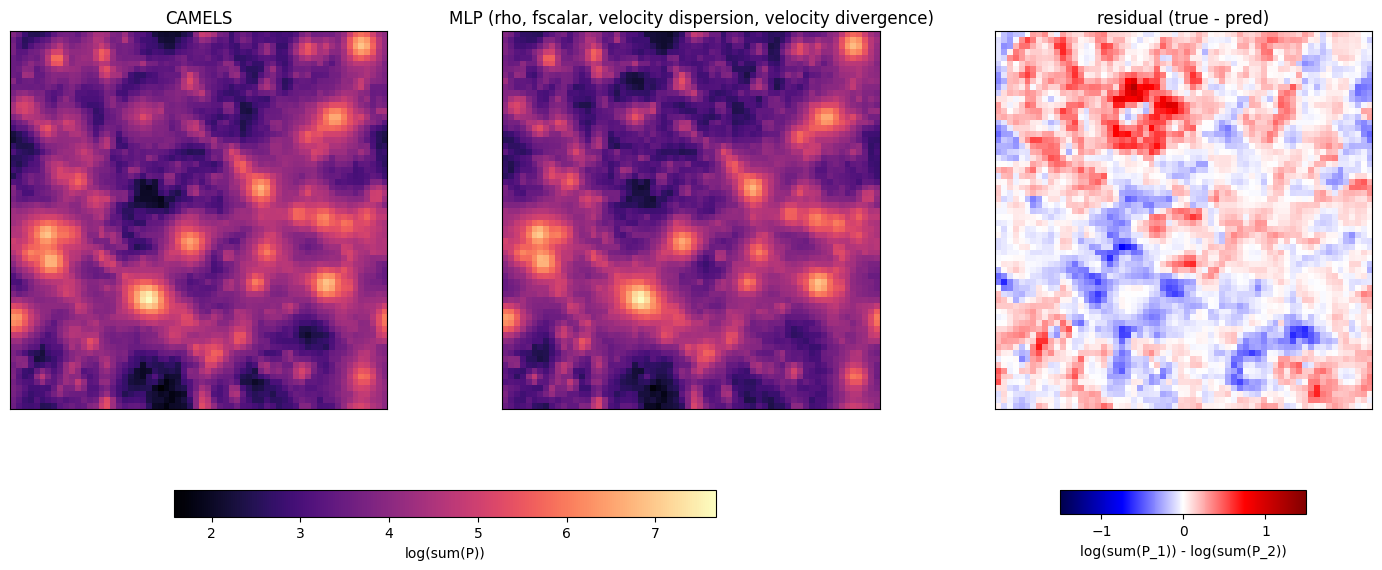

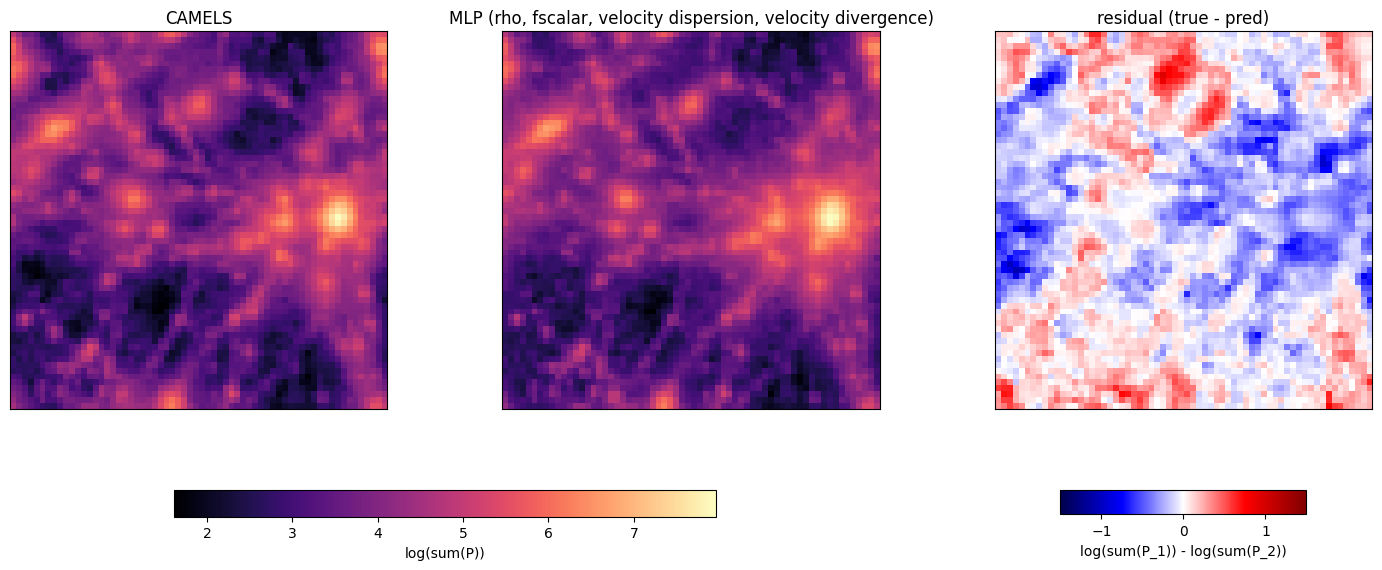

In [22]:
for i in tqdm.tqdm(range(total_steps)):
    x = X_particle
    y = Y
    
    params, opt_state, loss = train_step(params, opt_state, x, y)
    losses.append(loss)

model = nnx.merge(graphdef, params)

fig, ax = plt.subplots()
ax.plot(losses)
ax.set(yscale="log")

for snapshot_dict, label in zip([train_dict, test_dict], ["train", "test"]):
    X_particle_test, Y_test = get_data(snapshot_dict, velocity_features=True)
    
    gas_P_test = jnp.squeeze(10**model(X_particle_test) - 1)
    P_test = normalized_paint(snapshot_dict["gas_poss"], gas_P_test)
    
    P_camels = normalized_paint(snapshot_dict["gas_poss"], snapshot_dict["gas_Ps"])
    
    plot_comparison(P_camels, P_test, pred_label="MLP (rho, fscalar, velocity dispersion, velocity divergence)")
    print(label)